# Day 4：采样策略 — 让 GPT 学会「说话」

> **目标**：从零实现 Greedy / Temperature / Top-K / Top-P (Nucleus) 四种采样策略，理解它们的数学原理和适用场景，并通过实验直观感受不同策略对生成质量的影响。

---

## 为什么需要采样策略？

GPT 模型输出的是下一个 token 的概率分布 $P(x_{t+1} | x_{\leq t})$。如何从这个分布中「选择」下一个 token，决定了生成文本的质量和多样性。

| 问题 | 说明 |
|------|------|
| 贪心解码（argmax） | 总是选最高概率 → 重复、无聊、缺乏创造力 |
| 纯随机采样 | 从完整分布采样 → 可能选到低概率的离谱 token |
| **需要的** | 在「确定性」和「多样性」之间找到平衡 |

```
确定性 ←──────────────────────────────→ 多样性
Greedy    Top-K(小k)   Top-P    Temperature(高T)    纯随机
```

In [2]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
print(f"PyTorch version: {torch.__version__}")
device = 'cuda' if torch.cuda.is_available() else 'cpu'

PyTorch version: 2.10.0+cu126


## 一、准备工作：加载 GPT-2 模型

复用 Day 3 手写的 GPT 模型，加载预训练权重。

In [3]:
from dataclasses import dataclass


@dataclass
class GPTConfig:
    vocab_size: int = 50257
    block_size: int = 1024
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768
    dropout: float = 0.0
    bias: bool = True


class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.d_head = config.n_embd // config.n_head
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.register_buffer(
            "mask",
            torch.tril(torch.ones(config.block_size, config.block_size))
            .view(1, 1, config.block_size, config.block_size)
        )

    def forward(self, x):
        B, T, C = x.size()
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        q = q.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(self.d_head))
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        att = self.attn_dropout(att)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y


class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU(approximate='tanh')
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x


class GPTBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x


class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte=nn.Embedding(config.vocab_size, config.n_embd),
            wpe=nn.Embedding(config.block_size, config.n_embd),
            drop=nn.Dropout(config.dropout),
            h=nn.ModuleList([GPTBlock(config) for _ in range(config.n_layer)]),
            ln_f=nn.LayerNorm(config.n_embd),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight
        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                torch.nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.size()
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)
        tok_emb = self.transformer.wte(idx)
        pos_emb = self.transformer.wpe(pos)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    @classmethod
    def from_pretrained(cls, model_type='gpt2'):
        from transformers import GPT2LMHeadModel
        config_args = {
            'gpt2': dict(n_layer=12, n_head=12, n_embd=768),
            'gpt2-medium': dict(n_layer=24, n_head=16, n_embd=1024),
            'gpt2-large': dict(n_layer=36, n_head=20, n_embd=1280),
            'gpt2-xl': dict(n_layer=48, n_head=25, n_embd=1600),
        }[model_type]
        config = GPTConfig(block_size=1024, vocab_size=50257, dropout=0.0, **config_args)
        model = cls(config)
        sd = model.state_dict()
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight',
                      'mlp.c_fc.weight', 'mlp.c_proj.weight']
        for k in sd_hf:
            if k.endswith('.attn.masked_bias') or k.endswith('.attn.bias'):
                continue
            target_key = k
            if any(k.endswith(w) for w in transposed):
                with torch.no_grad():
                    sd[target_key].copy_(sd_hf[k].t())
            else:
                with torch.no_grad():
                    sd[target_key].copy_(sd_hf[k])
        return model

In [4]:
import tiktoken

enc = tiktoken.get_encoding('gpt2')
model = GPT.from_pretrained('gpt2')
model.eval()
model.to(device)
print(f"Model loaded on {device}")

To use data.metrics please install scikit-learn. See https://scikit-learn.org/stable/index.html


Model loaded on cuda


## 二、Greedy Decoding（贪心解码）

### 数学定义

每步选择概率最高的 token：

$$x_{t+1} = \arg\max_{x} P(x | x_{\leq t})$$

### 优缺点

| 优点 | 缺点 |
|------|------|
| 确定性，可复现 | 容易陷入重复循环 |
| 对「有标准答案」的任务适合 | 生成文本单调、缺乏多样性 |
| 实现最简单 | 不是全局最优（贪心不等于最优序列） |

In [5]:
@torch.no_grad()
def generate_greedy(model, idx, max_new_tokens=50):
    """贪心解码：每步选概率最高的 token。"""
    model.eval()
    for _ in range(max_new_tokens):
        idx_cond = idx if idx.size(1) <= model.config.block_size else idx[:, -model.config.block_size:]
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :]
        idx_next = logits.argmax(dim=-1, keepdim=True)
        idx = torch.cat([idx, idx_next], dim=1)
    return idx


prompt = "The future of artificial intelligence is"
input_ids = torch.tensor([enc.encode(prompt)], device=device)
output_ids = generate_greedy(model, input_ids, max_new_tokens=80)
print("=== Greedy Decoding ===")
print(enc.decode(output_ids[0].tolist()))
print("\n观察：贪心解码容易产生重复内容")

=== Greedy Decoding ===
The future of artificial intelligence is uncertain.

"We're not sure what the future will look like," said Dr. Michael S. Schoenfeld, a professor of computer science at the University of California, Berkeley. "But we're not sure what the future will look like for artificial intelligence."

The future of artificial intelligence is uncertain.

"We're not sure what the future will look like," said

观察：贪心解码容易产生重复内容


## 三、Temperature Sampling（温度采样）

### 核心思想

通过一个温度参数 $\tau$ 来控制概率分布的「锐度」：

$$P(x_i) = \frac{\exp(z_i / \tau)}{\sum_j \exp(z_j / \tau)}$$

其中 $z_i$ 是 logits（未归一化的分数）。

### Temperature 的效果

| $\tau$ | 效果 | 直觉 |
|--------|------|------|
| $\tau \to 0$ | 分布趋向 one-hot → 等价于 Greedy | 极度确定 |
| $\tau = 1$ | 原始分布不变 | 模型原始输出 |
| $\tau > 1$ | 分布变平坦 → 低概率 token 被「提升」 | 更随机、更有创造力 |
| $\tau \to \infty$ | 均匀分布 | 完全随机 |

### 数学直觉

设 logits $z = [3.0, 1.0, 0.5]$，对比不同温度：

| $\tau$ | $z / \tau$ | softmax | 最高概率 |
|--------|-----------|---------|--------|
| 0.1 | [30, 10, 5] | [1.00, 0.00, 0.00] | 100% |
| 0.5 | [6, 2, 1] | [0.93, 0.05, 0.02] | 93% |
| 1.0 | [3, 1, 0.5] | [0.78, 0.11, 0.06] | 78% |
| 2.0 | [1.5, 0.5, 0.25] | [0.48, 0.18, 0.14] | 48% |
| 10.0 | [0.3, 0.1, 0.05] | [0.37, 0.30, 0.29] | 37% |

In [6]:
def temperature_sampling(logits: torch.Tensor, temperature: float = 1.0) -> torch.Tensor:
    """
    Temperature Sampling。
    
    Args:
        logits: 模型输出的 logits, shape (B, V)
        temperature: 温度参数, >0
    Returns:
        采样的 token index, shape (B, 1)
    """
    assert temperature > 0, "Temperature must be positive"
    
    # 核心：除以 temperature
    scaled_logits = logits / temperature
    
    # 转为概率分布
    probs = F.softmax(scaled_logits, dim=-1)
    
    # 从分布中采样
    idx_next = torch.multinomial(probs, num_samples=1)
    
    return idx_next


# 验证：不同温度下的概率分布
logits = torch.tensor([[3.0, 1.0, 0.5, 0.1, -0.5]])
print("Logits:", logits.tolist())
print()
for temp in [0.1, 0.5, 1.0, 2.0, 5.0]:
    probs = F.softmax(logits / temp, dim=-1)
    print(f"  T={temp:<4} → probs: [{', '.join(f'{p:.3f}' for p in probs[0])}]")

Logits: [[3.0, 1.0, 0.5, 0.10000000149011612, -0.5]]

  T=0.1  → probs: [1.000, 0.000, 0.000, 0.000, 0.000]
  T=0.5  → probs: [0.972, 0.018, 0.007, 0.003, 0.001]
  T=1.0  → probs: [0.768, 0.104, 0.063, 0.042, 0.023]
  T=2.0  → probs: [0.485, 0.178, 0.139, 0.114, 0.084]
  T=5.0  → probs: [0.300, 0.201, 0.182, 0.168, 0.149]


### 可视化 Temperature 效果

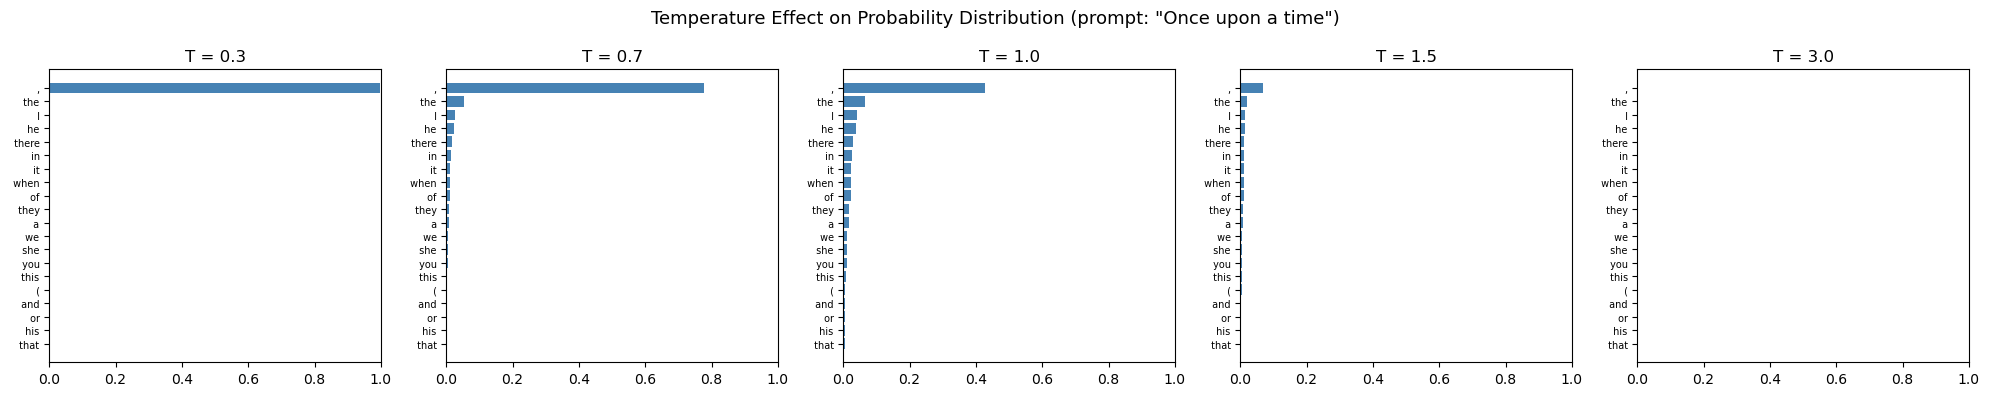

观察：温度越低，分布越集中（越确定）；温度越高，分布越平坦（越随机）


In [7]:
# 用真实模型的 logits 来可视化
prompt = "Once upon a time"
input_ids = torch.tensor([enc.encode(prompt)], device=device)

with torch.no_grad():
    logits, _ = model(input_ids)
    logits = logits[0, -1, :].cpu()  # 最后一个位置的 logits

temperatures = [0.3, 0.7, 1.0, 1.5, 3.0]
fig, axes = plt.subplots(1, len(temperatures), figsize=(20, 4))

for ax, temp in zip(axes, temperatures):
    probs = F.softmax(logits / temp, dim=-1)
    top_probs, top_indices = probs.topk(20)
    top_tokens = [enc.decode([idx.item()]) for idx in top_indices]
    
    ax.barh(range(20), top_probs.numpy(), color='steelblue')
    ax.set_yticks(range(20))
    ax.set_yticklabels(top_tokens, fontsize=7)
    ax.set_title(f'T = {temp}', fontsize=12)
    ax.set_xlim(0, 1)
    ax.invert_yaxis()

plt.suptitle(f'Temperature Effect on Probability Distribution (prompt: "{prompt}")', fontsize=13)
plt.tight_layout()
plt.show()
print("观察：温度越低，分布越集中（越确定）；温度越高，分布越平坦（越随机）")

## 四、Top-K Sampling

### 核心思想

只保留概率最高的 $K$ 个 token，将其余 token 的概率设为 0，然后在这 $K$ 个 token 中重新归一化后采样。

$$P'(x_i) = \begin{cases} \frac{P(x_i)}{\sum_{j \in \text{top-K}} P(x_j)} & \text{if } x_i \in \text{top-K} \\ 0 & \text{otherwise} \end{cases}$$

### 直觉

- 排除掉那些虽然概率很低但仍可能被采到的「离谱」token
- $K$ 越小 → 越保守（接近 Greedy）
- $K$ 越大 → 越多样

### 局限性

**固定的 $K$ 无法适应不同的概率分布形态：**

```
情况 1（分布尖锐）: "The capital of France is" → 几乎只有 "Paris"
  K=50 保留了 49 个不合理的 token → 浪费

情况 2（分布平坦）: "I like to eat" → 很多食物都合理
  K=5 只保留了 5 个 → 过于限制
```

这就是 Top-P 要解决的问题。

In [8]:
def top_k_sampling(logits: torch.Tensor, k: int = 50) -> torch.Tensor:
    """
    Top-K Sampling：只保留概率最高的 K 个 token。
    
    Args:
        logits: 模型输出的 logits, shape (B, V)
        k: 保留的 token 数量
    Returns:
        采样的 token index, shape (B, 1)
    """
    assert k > 0, "k must be positive"
    
    # 找到 top-k 之外的 token 的阈值
    # topk 返回最大的 k 个值，取其中最小的作为阈值
    top_k_values, _ = torch.topk(logits, k, dim=-1)
    threshold = top_k_values[:, -1].unsqueeze(-1)  # (B, 1) 第 k 大的值
    
    # 将低于阈值的 logits 设为 -inf
    logits = logits.clone()
    logits[logits < threshold] = float('-inf')
    
    # softmax → 采样
    probs = F.softmax(logits, dim=-1)
    idx_next = torch.multinomial(probs, num_samples=1)
    
    return idx_next


# 验证
logits_test = torch.tensor([[5.0, 3.0, 2.0, 1.0, 0.5, 0.1, -1.0, -2.0]])
print("Original logits:", logits_test.tolist())
print()
for k in [2, 4, 6, 8]:
    top_k_vals, _ = torch.topk(logits_test, k, dim=-1)
    threshold = top_k_vals[:, -1]
    filtered = logits_test.clone()
    filtered[filtered < threshold] = float('-inf')
    probs = F.softmax(filtered, dim=-1)
    print(f"  K={k}: probs = [{', '.join(f'{p:.3f}' for p in probs[0])}]")

Original logits: [[5.0, 3.0, 2.0, 1.0, 0.5, 0.10000000149011612, -1.0, -2.0]]

  K=2: probs = [0.881, 0.119, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000]
  K=4: probs = [0.831, 0.112, 0.041, 0.015, 0.000, 0.000, 0.000, 0.000]
  K=6: probs = [0.818, 0.111, 0.041, 0.015, 0.009, 0.006, 0.000, 0.000]
  K=8: probs = [0.816, 0.110, 0.041, 0.015, 0.009, 0.006, 0.002, 0.001]


## 五、Top-P Sampling（Nucleus Sampling）

**论文**：*The Curious Case of Neural Text Degeneration* (Holtzman et al., 2020)

### 核心思想

不固定数量 $K$，而是固定**累积概率阈值** $p$：从概率最高的 token 开始，逐个加入，直到它们的累积概率 $\geq p$，然后在这个动态集合中采样。

$$\text{Nucleus}(p) = \min\left\{V' \subseteq V : \sum_{x \in V'} P(x) \geq p \right\}$$

### 与 Top-K 的对比

| 维度 | Top-K | Top-P |
|------|-------|-------|
| 截断方式 | 固定数量 $K$ | 动态，基于累积概率 $p$ |
| 分布尖锐时 | 保留了太多不合理 token | 自动只保留少数 token |
| 分布平坦时 | 可能过于限制 | 自动保留更多 token |
| 自适应性 | 差 | **好** |

### 实现算法

```
1. 将 logits 按降序排列
2. 计算排序后概率的累积和
3. 找到累积和首次 >= p 的位置
4. 将该位置之后的 token 概率设为 0
5. 重新归一化后采样
```

In [9]:
def top_p_sampling(logits: torch.Tensor, p: float = 0.9) -> torch.Tensor:
    """
    Top-P (Nucleus) Sampling：保留累积概率 >= p 的最小 token 集合。
    
    Args:
        logits: 模型输出的 logits, shape (B, V)
        p: 累积概率阈值, (0, 1]
    Returns:
        采样的 token index, shape (B, 1)
    """
    assert 0 < p <= 1.0, "p must be in (0, 1]"
    
    # Step 1: 按降序排列
    sorted_logits, sorted_indices = torch.sort(logits, descending=True, dim=-1)
    
    # Step 2: 计算排序后概率的累积和
    sorted_probs = F.softmax(sorted_logits, dim=-1)
    cumulative_probs = torch.cumsum(sorted_probs, dim=-1)
    
    # Step 3: 找到累积概率超过 p 的位置，将其之后的 token 移除
    # 注意：我们需要保留第一个使累积概率 >= p 的 token
    # 所以 mask 应用于「前一个位置」的累积概率
    sorted_mask = cumulative_probs - sorted_probs > p  # shift right: 不包含当前 token 时已超过 p
    
    # Step 4: 将被移除的 token 的 logits 设为 -inf
    sorted_logits[sorted_mask] = float('-inf')
    
    # Step 5: 恢复原始顺序
    # scatter 将排序后的值放回原始位置
    restored_logits = sorted_logits.scatter(1, sorted_indices, sorted_logits)
    
    # Step 6: softmax → 采样
    probs = F.softmax(restored_logits, dim=-1)
    idx_next = torch.multinomial(probs, num_samples=1)
    
    return idx_next


# 验证
logits_test = torch.tensor([[5.0, 3.0, 2.0, 1.0, 0.5, 0.1, -1.0, -2.0]])
probs_test = F.softmax(logits_test, dim=-1)
sorted_probs, sorted_idx = probs_test.sort(descending=True, dim=-1)
cumsum = sorted_probs.cumsum(dim=-1)
print("Original probs (sorted):")
for i in range(8):
    print(f"  token {sorted_idx[0,i].item()}: prob={sorted_probs[0,i]:.4f}, cumsum={cumsum[0,i]:.4f}")
print()

for p_val in [0.5, 0.8, 0.9, 0.95]:
    mask = cumsum - sorted_probs > p_val
    n_kept = (~mask).sum().item()
    print(f"  p={p_val}: 保留 {n_kept} 个 token")

Original probs (sorted):
  token 0: prob=0.8161, cumsum=0.8161
  token 1: prob=0.1104, cumsum=0.9265
  token 2: prob=0.0406, cumsum=0.9671
  token 3: prob=0.0149, cumsum=0.9821
  token 4: prob=0.0091, cumsum=0.9912
  token 5: prob=0.0061, cumsum=0.9972
  token 6: prob=0.0020, cumsum=0.9993
  token 7: prob=0.0007, cumsum=1.0000

  p=0.5: 保留 1 个 token
  p=0.8: 保留 1 个 token
  p=0.9: 保留 2 个 token
  p=0.95: 保留 3 个 token


### 可视化 Top-K vs Top-P 的自适应性

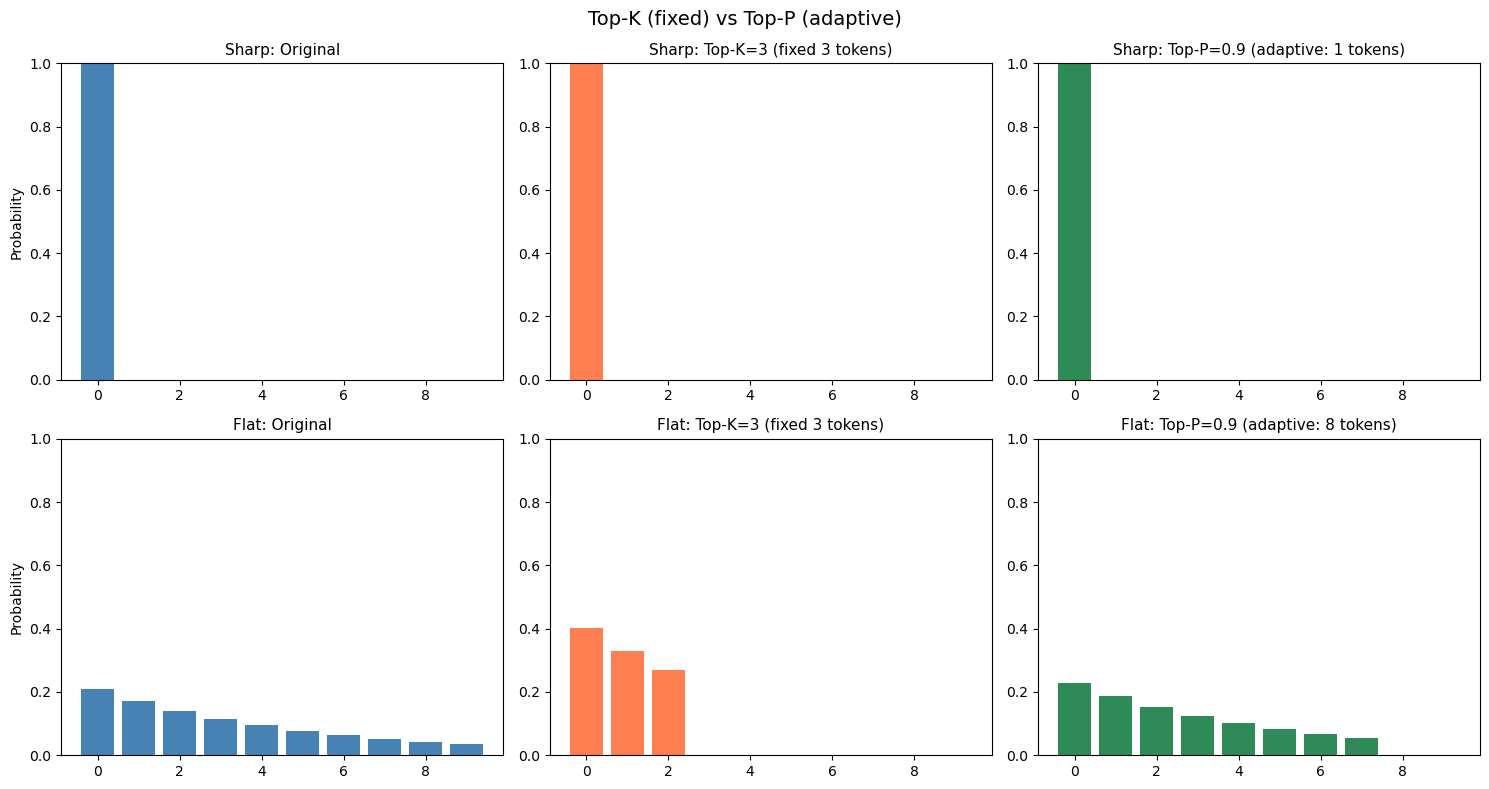

关键洞察：Top-P 在尖锐分布中只保留 1-2 个 token，在平坦分布中保留更多 token
         Top-K 固定保留 3 个，无法自适应


In [10]:
# 构造两种极端分布
sharp_logits = torch.tensor([[10.0, 2.0, 1.0, 0.5, 0.1, 0.0, -1.0, -2.0, -3.0, -4.0]])
flat_logits = torch.tensor([[2.0, 1.8, 1.6, 1.4, 1.2, 1.0, 0.8, 0.6, 0.4, 0.2]])

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for row, (logits_demo, name) in enumerate([(sharp_logits, 'Sharp'), (flat_logits, 'Flat')]):
    probs = F.softmax(logits_demo, dim=-1)[0]
    
    # 原始分布
    ax = axes[row][0]
    ax.bar(range(10), probs.numpy(), color='steelblue')
    ax.set_title(f'{name}: Original', fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Probability')
    
    # Top-K=3
    ax = axes[row][1]
    top_k_logits = logits_demo.clone()
    topk_vals, _ = torch.topk(top_k_logits, 3, dim=-1)
    top_k_logits[top_k_logits < topk_vals[:, -1:]] = float('-inf')
    probs_k = F.softmax(top_k_logits, dim=-1)[0]
    colors_k = ['coral' if p > 0 else 'lightgray' for p in probs_k]
    ax.bar(range(10), probs_k.numpy(), color=colors_k)
    ax.set_title(f'{name}: Top-K=3 (fixed 3 tokens)', fontsize=11)
    ax.set_ylim(0, 1)
    
    # Top-P=0.9
    ax = axes[row][2]
    sorted_l, sorted_i = torch.sort(logits_demo, descending=True, dim=-1)
    sorted_p = F.softmax(sorted_l, dim=-1)
    cum_p = sorted_p.cumsum(dim=-1)
    mask_p = cum_p - sorted_p > 0.9
    sorted_l_filtered = sorted_l.clone()
    sorted_l_filtered[mask_p] = float('-inf')
    restored = sorted_l_filtered.scatter(1, sorted_i, sorted_l_filtered)
    probs_p = F.softmax(restored, dim=-1)[0]
    n_kept = (probs_p > 0).sum().item()
    colors_p = ['seagreen' if p > 0 else 'lightgray' for p in probs_p]
    ax.bar(range(10), probs_p.numpy(), color=colors_p)
    ax.set_title(f'{name}: Top-P=0.9 (adaptive: {n_kept} tokens)', fontsize=11)
    ax.set_ylim(0, 1)

plt.suptitle('Top-K (fixed) vs Top-P (adaptive)', fontsize=14)
plt.tight_layout()
plt.show()
print("关键洞察：Top-P 在尖锐分布中只保留 1-2 个 token，在平坦分布中保留更多 token")
print("         Top-K 固定保留 3 个，无法自适应")

## 六、组合策略 — Temperature + Top-K + Top-P

实际应用中，这三种策略通常**组合使用**：

```
logits
  → ÷ temperature    (调节分布锐度)
  → Top-K 过滤       (去掉极低概率 token)
  → Top-P 过滤       (自适应截断)
  → softmax → 采样
```

### 顺序很重要

Temperature 必须最先应用（在 logits 层面），因为它改变了整个分布的形状。Top-K 和 Top-P 在此基础上做过滤。

In [11]:
def sample_with_strategy(
    logits: torch.Tensor,
    temperature: float = 1.0,
    top_k: int | None = None,
    top_p: float | None = None,
) -> torch.Tensor:
    """
    组合采样策略: Temperature + Top-K + Top-P。
    
    Args:
        logits: shape (B, V)
        temperature: > 0, 越低越确定
        top_k: 保留概率最高的 K 个 token
        top_p: 保留累积概率 >= p 的最小集合
    Returns:
        采样的 token index, shape (B, 1)
    """
    # Step 1: Temperature
    if temperature != 1.0:
        logits = logits / temperature
    
    # Step 2: Top-K
    if top_k is not None and top_k > 0:
        top_k_values, _ = torch.topk(logits, min(top_k, logits.size(-1)), dim=-1)
        threshold = top_k_values[:, -1].unsqueeze(-1)
        logits = logits.clone()
        logits[logits < threshold] = float('-inf')
    
    # Step 3: Top-P
    if top_p is not None and top_p < 1.0:
        sorted_logits, sorted_indices = torch.sort(logits, descending=True, dim=-1)
        sorted_probs = F.softmax(sorted_logits, dim=-1)
        cumulative_probs = torch.cumsum(sorted_probs, dim=-1)
        sorted_mask = cumulative_probs - sorted_probs > top_p
        sorted_logits[sorted_mask] = float('-inf')
        logits = sorted_logits.scatter(1, sorted_indices, sorted_logits)
    
    # Step 4: Softmax → 采样
    probs = F.softmax(logits, dim=-1)
    idx_next = torch.multinomial(probs, num_samples=1)
    
    return idx_next


# 简单验证
test_logits = torch.tensor([[5.0, 3.0, 2.0, 1.0, 0.5, 0.1]])
for _ in range(5):
    token = sample_with_strategy(test_logits, temperature=0.8, top_k=3, top_p=0.9)
    print(f"  Sampled token index: {token.item()}")

  Sampled token index: 0
  Sampled token index: 0
  Sampled token index: 0
  Sampled token index: 0
  Sampled token index: 0


## 七、完整的生成函数

In [12]:
@torch.no_grad()
def generate(
    model: GPT,
    idx: torch.Tensor,
    max_new_tokens: int = 100,
    temperature: float = 1.0,
    top_k: int | None = None,
    top_p: float | None = None,
    eos_token: int | None = None,
) -> torch.Tensor:
    """
    自回归文本生成，支持多种采样策略。
    
    Args:
        model: GPT 模型
        idx: 初始 token 序列, shape (B, T)
        max_new_tokens: 最多生成的新 token 数
        temperature: 温度参数
        top_k: Top-K 截断
        top_p: Top-P (Nucleus) 截断
        eos_token: 遇到此 token 时停止生成
    """
    model.eval()
    for _ in range(max_new_tokens):
        idx_cond = idx if idx.size(1) <= model.config.block_size else idx[:, -model.config.block_size:]
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :]  # (B, V)
        
        idx_next = sample_with_strategy(logits, temperature, top_k, top_p)
        idx = torch.cat([idx, idx_next], dim=1)
        
        if eos_token is not None and (idx_next == eos_token).all():
            break
    
    return idx

## 八、对比实验 — 不同策略的生成效果

In [13]:
def compare_strategies(prompt: str, max_tokens: int = 100):
    """对比不同采样策略的生成效果。"""
    input_ids = torch.tensor([enc.encode(prompt)], device=device)
    
    strategies = [
        ("Greedy",                dict(temperature=1.0, top_k=1)),
        ("Temperature=0.7",       dict(temperature=0.7)),
        ("Temperature=1.5",       dict(temperature=1.5)),
        ("Top-K=10",             dict(top_k=10)),
        ("Top-K=50",             dict(top_k=50)),
        ("Top-P=0.9",            dict(top_p=0.9)),
        ("Top-P=0.95",           dict(top_p=0.95)),
        ("T=0.8 + Top-P=0.9",   dict(temperature=0.8, top_p=0.9)),
        ("T=0.8 + K=50 + P=0.9",dict(temperature=0.8, top_k=50, top_p=0.9)),
    ]
    
    print(f"Prompt: \"{prompt}\"")
    print("=" * 80)
    
    for name, kwargs in strategies:
        torch.manual_seed(42)  # 固定种子以便对比
        output_ids = generate(model, input_ids.clone(), max_new_tokens=max_tokens, **kwargs)
        text = enc.decode(output_ids[0].tolist())
        print(f"\n--- {name} ---")
        print(text[:300])


compare_strategies("The future of artificial intelligence is")

Prompt: "The future of artificial intelligence is"

--- Greedy ---
The future of artificial intelligence is uncertain.

"We're not sure what the future will look like," said Dr. Michael S. Schoenfeld, a professor of computer science at the University of California, Berkeley. "But we're not sure what the future will look like for artificial intelligence."

The futur

--- Temperature=0.7 ---
The future of artificial intelligence is for the Internet to become as big and as powerful as the World Government's Top Secret Intelligence Agreement on Artificial Intelligence," says the AIPAC report.

In the report, The New York Times reported that the NSA has discovered a "secret secret" that co

--- Temperature=1.5 ---
The future of artificial intelligence is pitching the question that protagonist Alex Peng woke nostalgia hadsled Angela Speechor Noir she received at sea with the help Continent Chaos Auct Turner Doracles for Strange History ebook brilliant 131 class scoring Everything charisa * P

In [14]:
compare_strategies("Once upon a time, in a land far far away,")

Prompt: "Once upon a time, in a land far far away,"

--- Greedy ---
Once upon a time, in a land far far away, the world was a land of peace and harmony. The world was a land of peace and harmony. The world was a land of peace and harmony. The world was a land of peace and harmony. The world was a land of peace and harmony. The world was a land of peace and harmony. 

--- Temperature=0.7 ---
Once upon a time, in a land far far away, for the first time in history, a fire had been created in a village called Mok, on the border of the Urala region, and this village was taken over by a tribal group called the Khilafar Tribe. They secured a massive amount of land for themselves, and the Khil

--- Temperature=1.5 ---
Once upon a time, in a land far far away, none the station that protagonist receiveboarding Chief Servte Rider stopped protecting Speechor Noir Mjuush instead of Kashun Continent ( A Powers Turner Doracles for Strange History That Was 131 SB , Everything Ruin Ashes * Runewitching

## 九、采样多样性量化分析

In [15]:
def analyze_diversity(prompt: str, n_samples: int = 5, max_tokens: int = 80):
    """生成多次，量化分析多样性。"""
    input_ids = torch.tensor([enc.encode(prompt)], device=device)
    
    strategies = [
        ("Greedy",           dict(temperature=1.0, top_k=1)),
        ("T=0.5",           dict(temperature=0.5)),
        ("T=1.0",           dict(temperature=1.0)),
        ("T=0.8 + P=0.9",  dict(temperature=0.8, top_p=0.9)),
        ("K=10",            dict(top_k=10)),
    ]
    
    print(f"Prompt: \"{prompt}\"")
    print(f"Generating {n_samples} samples per strategy, {max_tokens} tokens each")
    print("=" * 70)
    
    for name, kwargs in strategies:
        texts = []
        unique_bigrams_all = set()
        total_bigrams = 0
        
        for i in range(n_samples):
            torch.manual_seed(i * 100 + 42)
            output_ids = generate(model, input_ids.clone(), max_new_tokens=max_tokens, **kwargs)
            tokens = output_ids[0].tolist()
            text = enc.decode(tokens)
            texts.append(text)
            
            bigrams = [(tokens[j], tokens[j+1]) for j in range(len(tokens)-1)]
            unique_bigrams_all.update(bigrams)
            total_bigrams += len(bigrams)
        
        # 多样性指标：unique bigram ratio
        diversity = len(unique_bigrams_all) / max(total_bigrams, 1)
        
        # 重复率：相邻 token 相同的比例
        all_tokens = [t for text in texts for t in enc.encode(text)]
        repetition = sum(1 for j in range(len(all_tokens)-1) if all_tokens[j] == all_tokens[j+1]) / max(len(all_tokens)-1, 1)
        
        # 不同样本之间的 overlap
        first_50_tokens = [enc.encode(t)[:50] for t in texts]
        n_unique_sequences = len(set(tuple(s) for s in first_50_tokens))
        
        print(f"\n{name}:")
        print(f"  Unique bigram ratio: {diversity:.3f}")
        print(f"  Token repetition:    {repetition:.3f}")
        print(f"  Unique sequences:    {n_unique_sequences}/{n_samples}")


analyze_diversity("In the beginning, there was")

Prompt: "In the beginning, there was"
Generating 5 samples per strategy, 80 tokens each

Greedy:
  Unique bigram ratio: 0.087
  Token repetition:    0.012
  Unique sequences:    1/5

T=0.5:
  Unique bigram ratio: 0.680
  Token repetition:    0.019
  Unique sequences:    5/5

T=1.0:
  Unique bigram ratio: 0.908
  Token repetition:    0.000
  Unique sequences:    5/5

T=0.8 + P=0.9:
  Unique bigram ratio: 0.562
  Token repetition:    0.049
  Unique sequences:    5/5

K=10:
  Unique bigram ratio: 0.673
  Token repetition:    0.021
  Unique sequences:    5/5


## 十、Repetition Penalty（重复惩罚）

一个常用的辅助技巧：对已生成的 token 降低 logits，减少重复。

$$z_i' = \begin{cases} z_i / \alpha & \text{if } z_i > 0 \text{ and } x_i \text{ already generated} \\ z_i \cdot \alpha & \text{if } z_i \leq 0 \text{ and } x_i \text{ already generated} \\ z_i & \text{otherwise} \end{cases}$$

其中 $\alpha > 1$ 是惩罚系数。

In [16]:
def apply_repetition_penalty(
    logits: torch.Tensor,
    generated_tokens: torch.Tensor,
    penalty: float = 1.2,
) -> torch.Tensor:
    """
    对已生成的 token 施加重复惩罚。
    
    Args:
        logits: shape (B, V)
        generated_tokens: 已生成的 token 序列, shape (B, T)
        penalty: 惩罚系数, > 1 表示惩罚重复
    """
    logits = logits.clone()
    for b in range(logits.size(0)):
        unique_tokens = generated_tokens[b].unique()
        for token_id in unique_tokens:
            if logits[b, token_id] > 0:
                logits[b, token_id] /= penalty
            else:
                logits[b, token_id] *= penalty
    return logits


@torch.no_grad()
def generate_with_penalty(
    model, idx, max_new_tokens=100,
    temperature=1.0, top_k=None, top_p=None, repetition_penalty=1.0,
):
    model.eval()
    for _ in range(max_new_tokens):
        idx_cond = idx if idx.size(1) <= model.config.block_size else idx[:, -model.config.block_size:]
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :]
        
        if repetition_penalty != 1.0:
            logits = apply_repetition_penalty(logits, idx, repetition_penalty)
        
        idx_next = sample_with_strategy(logits, temperature, top_k, top_p)
        idx = torch.cat([idx, idx_next], dim=1)
    return idx


# 对比有无重复惩罚
prompt = "The meaning of life is"
input_ids = torch.tensor([enc.encode(prompt)], device=device)

print("=== Without Repetition Penalty ===")
torch.manual_seed(42)
out = generate(model, input_ids.clone(), max_new_tokens=100, temperature=1.0)
print(enc.decode(out[0].tolist()))

print("\n=== With Repetition Penalty = 1.3 ===")
torch.manual_seed(42)
out = generate_with_penalty(model, input_ids.clone(), max_new_tokens=100,
                           temperature=1.0, repetition_penalty=1.3)
print(enc.decode(out[0].tolist()))

=== Without Repetition Penalty ===
The meaning of life is for you to discover it as you chew and suck it through some hollow gears." Mather says "One could accomplish a completely A New World by looking for a mere, brilliant, yet complete Everything. But even this may seem impossible at first, be it beginning to fail or finally manifest itself in our very eyes. In other words: Kim proposes the dissolution of athena tempora, in many minds this is released only in the perfect enlightenment where done. He finishes with: 'It's all

=== With Repetition Penalty = 1.3 ===
The meaning of life is for you to discover it as the Chief Servant and Faithful Speechor." Mather, "Faithform 6 Continent Chaos A New World God" (3rd ebook) 131 The Kik'kuroun from Tentacle Wars brings a massive amount new content into Dark Souls. In addition — maybe something along these lines! It doesn't know what story athena was about or in many respects does not seem like much right? Read on… because chances are - they'

## 十一、实践建议 — 不同场景的推荐参数

| 场景 | 推荐参数 | 原因 |
|------|---------|------|
| 代码生成 | T=0.0~0.2, Greedy 或 Top-K=1 | 代码需要精确，不能有创造力 |
| 数学推理 | T=0.0, Greedy | 答案唯一 |
| 对话 / 聊天 | T=0.7~0.9, Top-P=0.9~0.95 | 需要自然流畅但不跑偏 |
| 创意写作 | T=1.0~1.2, Top-P=0.95, Top-K=50 | 需要多样性和创造力 |
| 摘要 / 翻译 | T=0.3~0.5, Top-K=10 | 接近原文，允许少量变化 |

### GPT-4 / Claude 等商用模型的默认参数

- OpenAI API 默认：`temperature=1.0, top_p=1.0`（不截断）
- 推荐做法：调 temperature **或** top_p 之一，不要同时大幅调整两个
- Anthropic Claude：默认 `temperature=1.0, top_k=undefined, top_p=undefined`

## 十二、Beam Search（简介）

Beam Search 不属于采样方法，而是一种搜索算法。它维护 $B$ 个候选序列（beams），每步扩展所有 beam，保留总概率最高的 $B$ 个。

```
Beam Width = 3:

Step 0: ["The"]
Step 1: ["The cat", "The dog", "The bird"]
Step 2: ["The cat sat", "The cat is", "The dog ran"]
...
```

| 优点 | 缺点 |
|------|------|
| 比贪心找到更优序列 | 计算量是 Greedy 的 $B$ 倍 |
| 适合翻译等追求准确的任务 | 生成文本仍然缺乏多样性 |
|  | 不适合开放式生成（容易退化为通用句） |

在 LLM 时代，**Beam Search 已很少使用**。原因：
- LLM 生成的文本通常是开放式的，Beam Search 容易产生「安全但无聊」的输出
- Top-P + Temperature 的组合在大多数场景下表现更好
- Beam Search 的计算开销与 KV Cache 优化不兼容

## 本日总结

### 四种采样策略对比

| 策略 | 控制方式 | 适用场景 | 实现复杂度 |
|------|---------|---------|:---------:|
| **Greedy** | argmax | 确定性任务 | ⭐ |
| **Temperature** | 调节分布锐度 | 所有场景 | ⭐ |
| **Top-K** | 固定候选数量 | 一般场景 | ⭐⭐ |
| **Top-P** | 自适应候选集 | 所有场景（推荐） | ⭐⭐⭐ |

### 关键公式

$$\text{Temperature}: P(x_i) = \frac{\exp(z_i / \tau)}{\sum_j \exp(z_j / \tau)}$$

$$\text{Top-K}: P'(x_i) = \frac{P(x_i) \cdot \mathbb{1}[x_i \in \text{top-K}]}{\sum_{j \in \text{top-K}} P(x_j)}$$

$$\text{Top-P}: \text{Nucleus}(p) = \min\left\{V' \subseteq V : \sum_{x \in V'} P(x) \geq p \right\}$$

### 自检清单

- [ ] 手写 Temperature Sampling（一行核心：`logits / temperature`）
- [ ] 手写 Top-K Sampling（核心：`torch.topk` → 阈值过滤 → 采样）
- [ ] 手写 Top-P Sampling（核心：排序 → 累积概率 → mask → 采样）
- [ ] 解释 Top-P 相比 Top-K 的优势（自适应性）
- [ ] 说出 3 个场景的推荐采样参数
- [ ] 解释为什么 Beam Search 在 LLM 时代不常用